# Clustering jerarquico

Este notebook usa **`data/Estudiantes.xlsx`** (calificaciones por asignatura).

1. **Validacion de clusterabilidad** antes de agrupar: estadistico de Hopkins y mapa tipo **VAT** (matriz de distancias ordenada).
2. **Modelo**: varias **metricas** (euclidea, Manhattan, coseno) y **enlaces** *single* (salto minimo), *complete* (maximo), *average* (promedio) y **Ward** (solo con euclidea).
3. **Interpretacion**: dendrogramas, silueta, PCA, perfiles en barras, mapa de calor de medias, grafico de arana, correlacion cophenetica.

> Con \(n=10\) estudiantes, Hopkins y silueta son **orientativos** (alta varianza). El foco es comparar **formas de dendrograma** y **perfiles** entre configuraciones.

In [25]:

from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Carpeta de modulos reutilizables
ROOT = Path.cwd()
SCRIPTS = ROOT / "scripts"
if str(SCRIPTS.resolve()) not in sys.path:
    sys.path.insert(0, str(SCRIPTS.resolve()))

from clusterability import hopkins_statistic, vat_order
from data_prep import load_students_excel, scale_features
from hierarchical_clustering import (
    default_specs,
    grid_silhouette,
    labels_sklearn,
    linkage_matrix,
)
from plot_arania import plot_radar_profiles
from plot_barras import plot_cluster_sizes, plot_mean_profile_bars
from plot_cophenetico import plot_cophenetic_bars
from plot_curva_silhouette import plot_silhouette_vs_k
from plot_dendrogramas import plot_dendrogram
from plot_mapa_calor import plot_distance_heatmap, plot_vat_heatmap
from plot_pca import plot_pca_scatter
from plot_perfil_calor import plot_cluster_profile_heatmap
from plot_silhouette import plot_silhouette

sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline


In [26]:

df, name_col, feature_cols = load_students_excel()
display(df)
print("Variables numericas:", feature_cols)


,Nombre,Matematica,Ciencias,Español,Historia,Educacion F
0,Lucia,7.0,6.5,9.2,8.6,8.0
1,Pedro,7.5,9.4,7.3,7.0,7.0
2,Ines,7.6,9.2,8.0,8.0,7.5
3,Luis,5.0,6.5,6.5,7.0,9.0
4,Andres,6.0,6.0,7.8,8.9,7.3
5,Ana,7.8,9.6,7.7,8.0,6.5
6,Carlos,6.3,6.4,8.2,9.0,7.2
7,Jose,7.9,9.7,7.5,8.0,6.0
8,Sonia,6.0,6.0,6.5,5.5,8.7
9,Maria,6.8,7.2,8.7,9.0,7.0


Variables numericas: ['Matematica', 'Ciencias', 'Español', 'Historia', 'Educacion F']


## 1) Clusterabilidad (antes del modelo)

In [27]:

X_raw = df[feature_cols].to_numpy(dtype=float)
H = hopkins_statistic(X_raw, seed=42)
print(f"Hopkins (datos sin escalar): {H:.3f}")
print("Interpretacion rapida: ~0.5 sugiere poca estructura vs uniforme; valores mayores sugieren mas tendencia a grupos.")


Hopkins (datos sin escalar): 0.663
Interpretacion rapida: ~0.5 sugiere poca estructura vs uniforme; valores mayores sugieren mas tendencia a grupos.


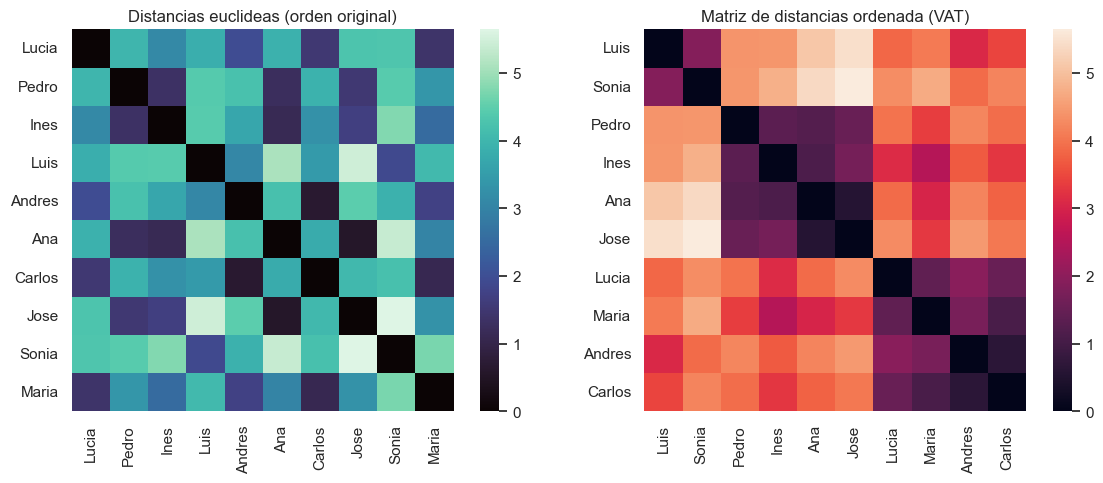

In [28]:

order, D_ord = vat_order(X_raw, metric="euclidean")
names = df[name_col].astype(str).tolist()
ordered_names = [names[i] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_distance_heatmap(X_raw, names, metric="euclidean", ax=axes[0], title="Distancias euclideas (orden original)")
plot_vat_heatmap(D_ord, ordered_names, ax=axes[1])
plt.show()


## 2) Estandarizacion (recomendada antes de distancias)

In [29]:

X, scaler, X_scaled_df = scale_features(df, feature_cols)
X_scaled_df.head()


,Matematica,Ciencias,Español,Historia,Educacion F
0,0.232631,-0.752986,1.788485,0.657923,0.658581
1,0.786514,1.145849,-0.538996,-0.845901,-0.476903
2,0.897290,1.014894,0.318497,0.093989,0.090839
3,-1.982900,-0.752986,-1.518987,-0.845901,1.794065
4,-0.875135,-1.080371,0.073499,0.939889,-0.136258


## 3) Clustering jerarquico: todas las combinaciones didacticas

In [30]:

specs = default_specs()
print(f"Total de configuraciones: {len(specs)}")
for s in specs:
    print("-", s.label)


Total de configuraciones: 10
- euclidea | salto minimo (single)
- euclidea | salto maximo (complete)
- euclidea | enlace promedio (average)
- euclidea | Ward (min. varianza intra)
- Manhattan (L1) | salto minimo (single)
- Manhattan (L1) | salto maximo (complete)
- Manhattan (L1) | enlace promedio (average)
- coseno | salto minimo (single)
- coseno | salto maximo (complete)
- coseno | enlace promedio (average)


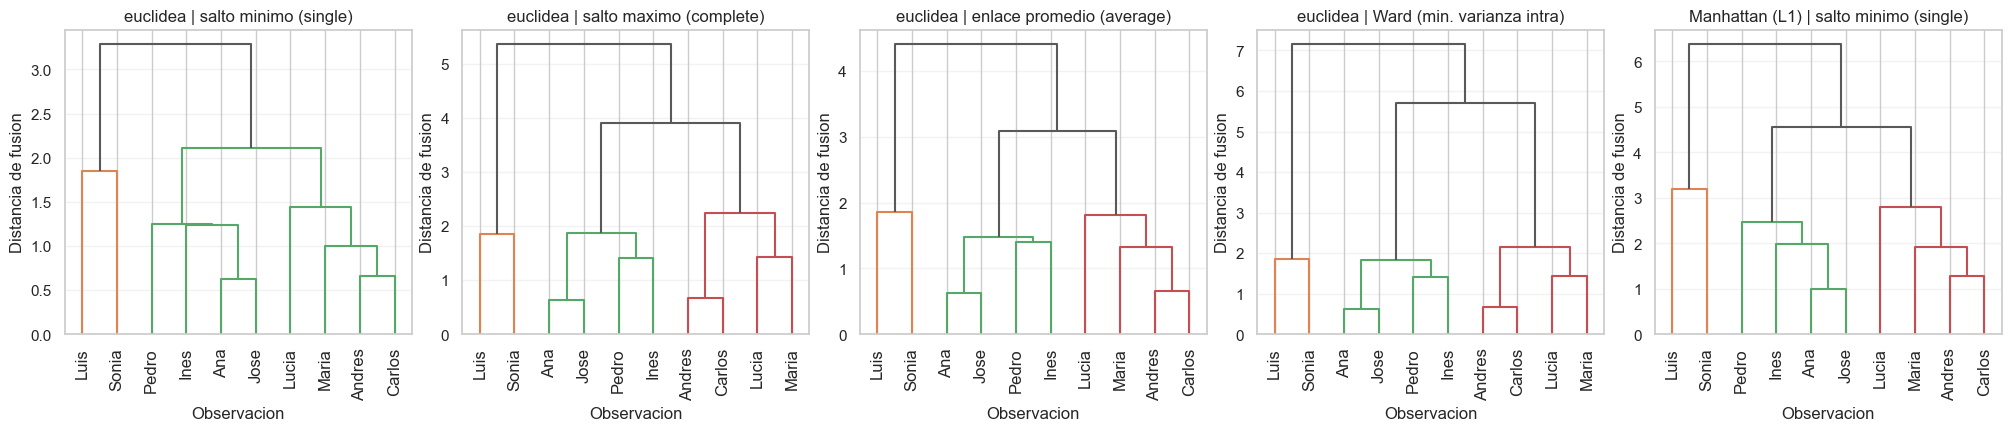

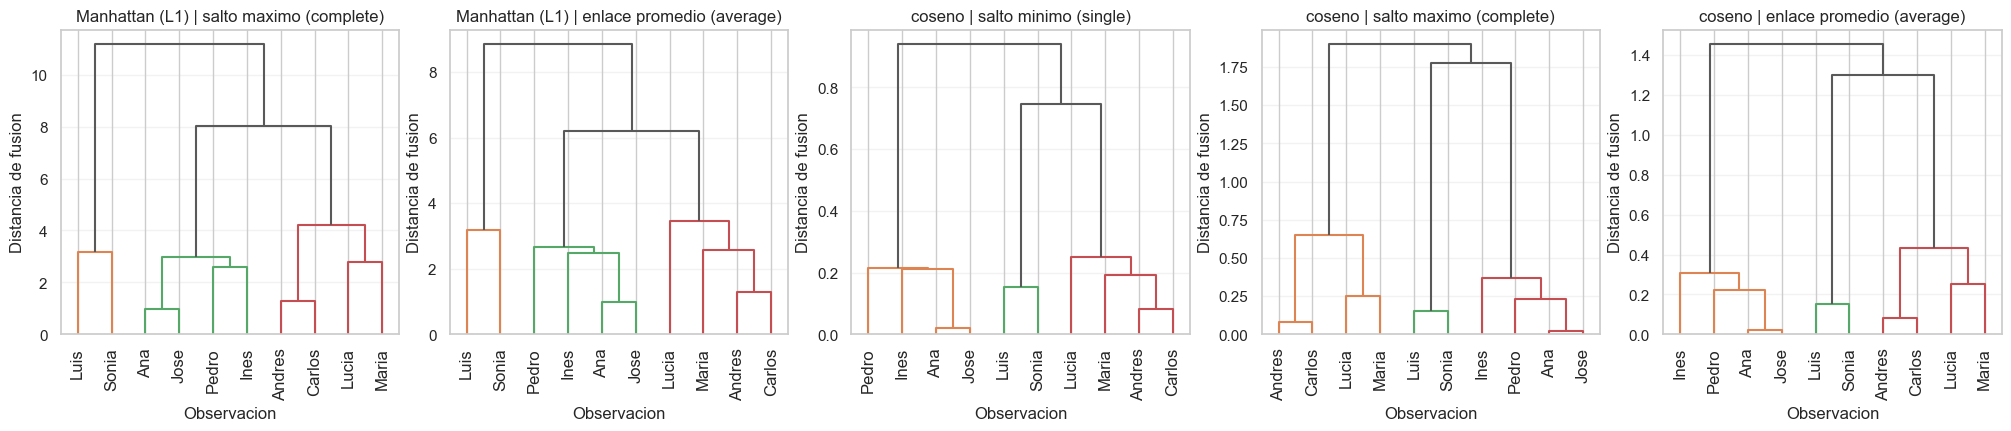

In [31]:

# Dendrogramas (una figura por bloque para legibilidad)
names = df[name_col].astype(str).tolist()

for row in range(0, len(specs), 5):
    chunk = specs[row : row + 5]
    fig, axes = plt.subplots(1, len(chunk), figsize=(4 * len(chunk), 4.2), constrained_layout=True)
    if len(chunk) == 1:
        axes = [axes]
    for ax, spec in zip(axes, chunk):
        Z = linkage_matrix(X, spec)
        plot_dendrogram(Z, names, ax=ax, title=spec.label)
    plt.show()


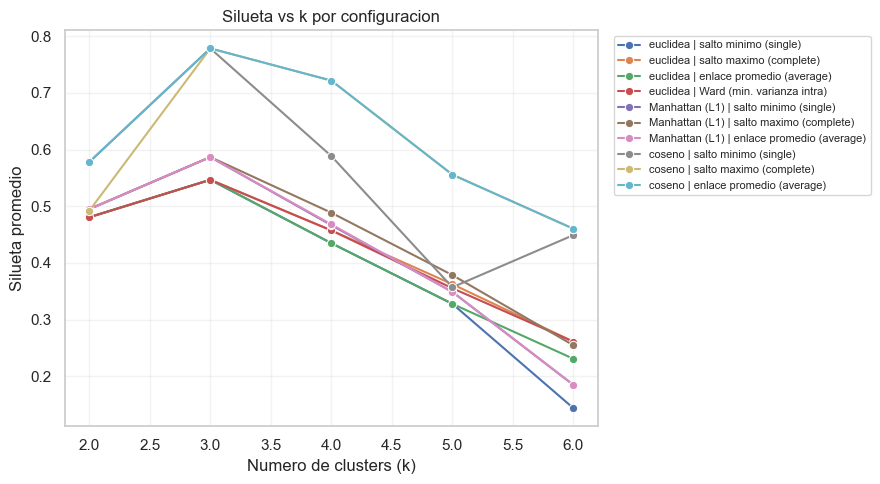

,spec,metric,linkage,k,silhouette
36,coseno | salto minimo (single),cosine,single,3,0.778404
41,coseno | salto maximo (complete),cosine,complete,3,0.778404
46,coseno | enlace promedio (average),cosine,average,3,0.778404
42,coseno | salto maximo (complete),cosine,complete,4,0.721642
47,coseno | enlace promedio (average),cosine,average,4,0.721642
37,coseno | salto minimo (single),cosine,single,4,0.588498
21,Manhattan (L1) | salto minimo (single),manhattan,single,3,0.586751
26,Manhattan (L1) | salto maximo (complete),manhattan,complete,3,0.586751
31,Manhattan (L1) | enlace promedio (average),manhattan,average,3,0.586751
35,coseno | salto minimo (single),cosine,single,2,0.578070


In [32]:

# Silueta promedio vs k (todas las configuraciones; puede verse ruidosa con n pequeno)
plot_silhouette_vs_k(X, specs, k_min=2, k_max=min(6, X.shape[0] - 1))
plt.show()

grid = grid_silhouette(X, specs, k_min=2, k_max=min(6, X.shape[0] - 1))
display(grid.sort_values(["silhouette", "k"], ascending=[False, True]).head(15))


/Users/rachitvargaslopez/Documents/LEAD University/Mineria de datos/data_science/data_mining/7 - clustering_jerarquico/scripts/plot_cophenetico.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y="spec", x="cophenetic", ax=ax, palette="crest")


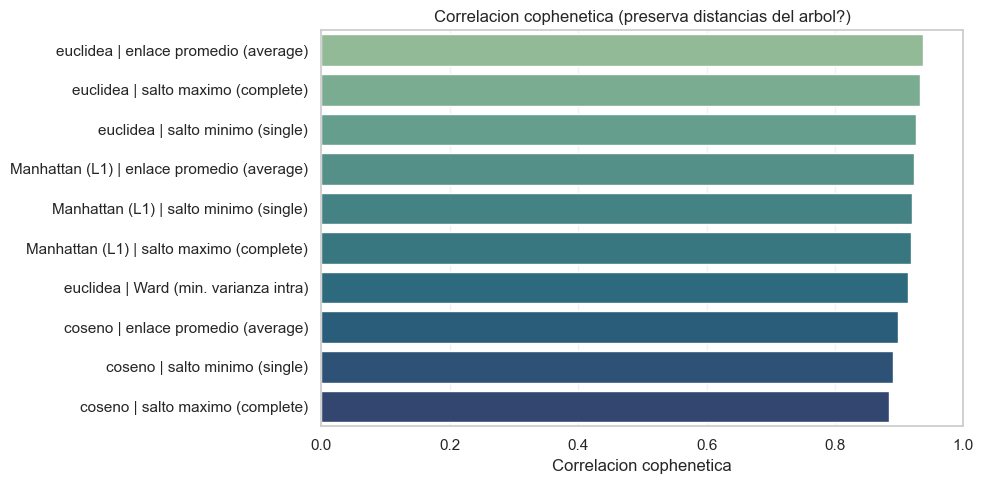

In [33]:

plot_cophenetic_bars(X, specs, title="Correlacion cophenetica (preserva distancias del arbol?)")
plt.show()


## 4) Elegir una configuracion para interpretar en detalle

In [34]:

# Elegimos (k, spec) con mayor silueta promedio (ignorando NaN)
valid = grid.dropna(subset=["silhouette"])
if valid.empty:
    raise RuntimeError("No hay siluetas validas; revisa k o los datos.")

best = valid.sort_values("silhouette", ascending=False).iloc[0]
best_k = int(best["k"])
best_label = str(best["spec"])
best_spec = next(s for s in specs if s.label == best_label)

print("Mejor fila (heuristica):", best.to_dict())

labels = labels_sklearn(X, best_spec, n_clusters=best_k)
print("Etiquetas:", labels)


Mejor fila (heuristica): {'spec': 'coseno | enlace promedio (average)', 'metric': 'cosine', 'linkage': 'average', 'k': 3, 'silhouette': 0.778403884105064}
Etiquetas: [0 1 1 2 0 1 0 1 2 0]


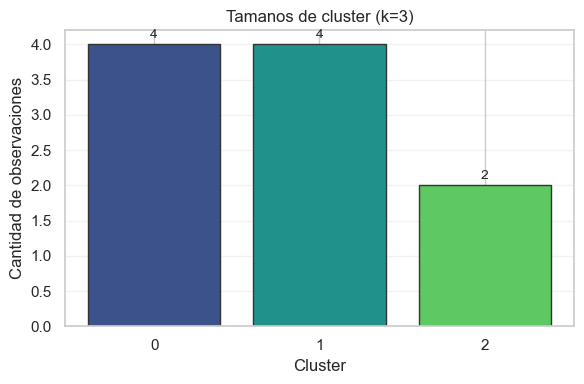

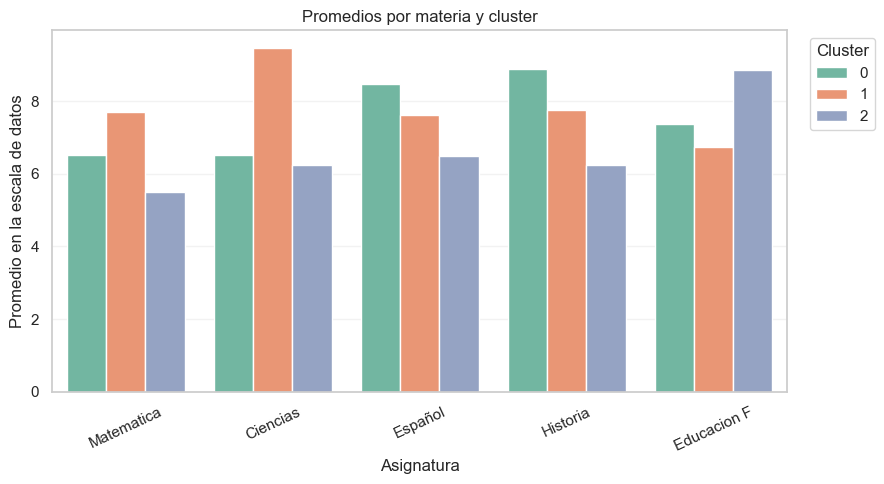

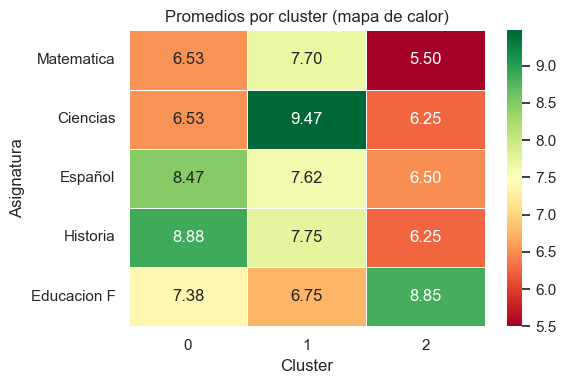

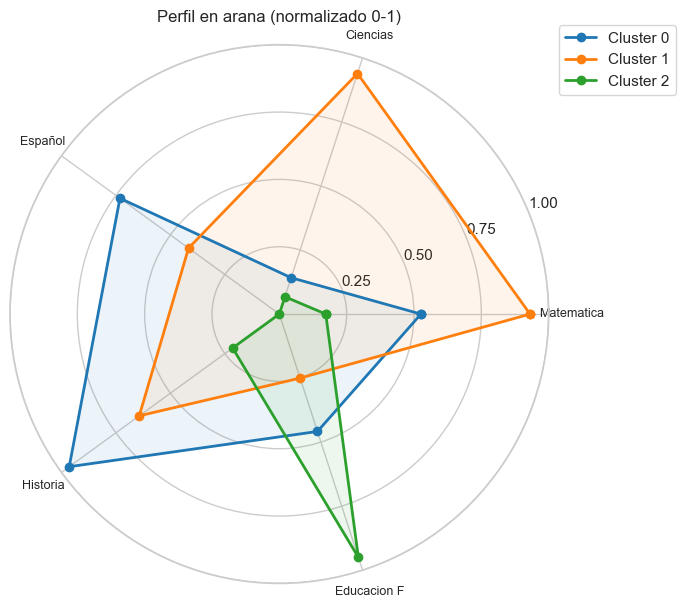

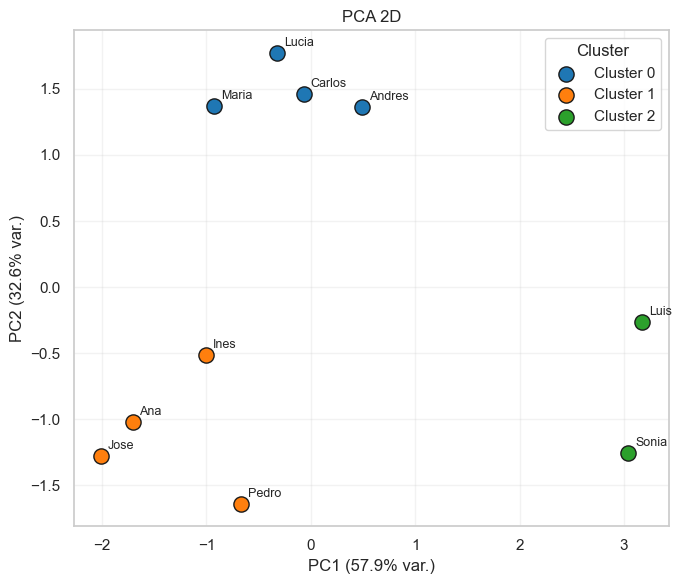

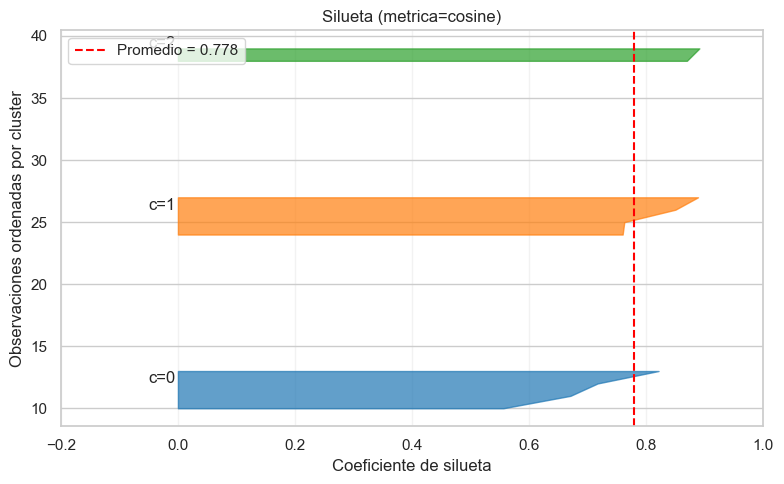

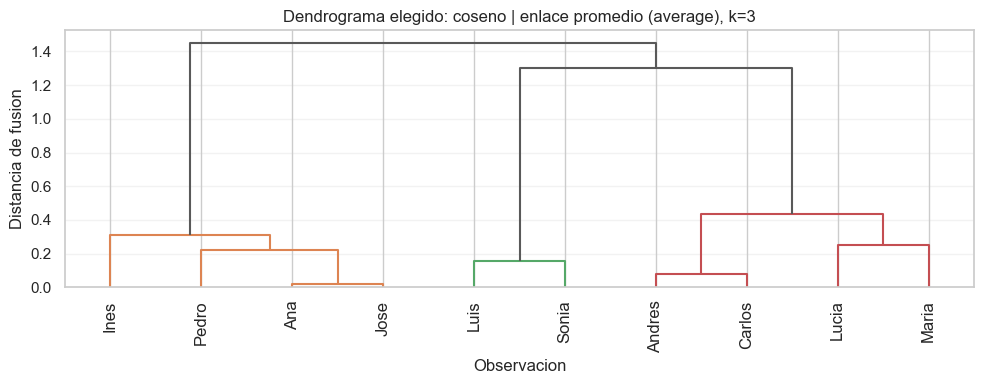

In [35]:

# Graficos de interpretacion (modulos en /scripts)
metric_sil = "euclidean" if best_spec.linkage == "ward" else best_spec.sklearn_metric()

fig, ax = plt.subplots(figsize=(6, 4))
plot_cluster_sizes(labels, ax=ax, title=f"Tamanos de cluster (k={best_k})")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
plot_mean_profile_bars(df, feature_cols, labels, ax=ax, title="Promedios por materia y cluster")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
plot_cluster_profile_heatmap(df, feature_cols, labels, ax=ax)
plt.show()

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)
plot_radar_profiles(df, feature_cols, labels, ax=ax, title="Perfil en arana (normalizado 0-1)")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
plot_pca_scatter(X, labels, df[name_col], feature_cols, ax=ax, title="PCA 2D")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
plot_silhouette(X, labels, metric=metric_sil, ax=ax, title=f"Silueta (metrica={metric_sil})")
plt.show()

Z_best = linkage_matrix(X, best_spec)
fig, ax = plt.subplots(figsize=(10, 4))
plot_dendrogram(Z_best, names, ax=ax, title=f"Dendrograma elegido: {best_spec.label}, k={best_k}")
plt.show()


## 5) Tabla resumen por estudiante

In [36]:

out = df[[name_col] + feature_cols].copy()
out["cluster"] = labels
display(out.sort_values(["cluster", name_col]))


,Nombre,Matematica,Ciencias,Español,Historia,Educacion F,cluster
4,Andres,6.0,6.0,7.8,8.9,7.3,0
6,Carlos,6.3,6.4,8.2,9.0,7.2,0
0,Lucia,7.0,6.5,9.2,8.6,8.0,0
9,Maria,6.8,7.2,8.7,9.0,7.0,0
5,Ana,7.8,9.6,7.7,8.0,6.5,1
2,Ines,7.6,9.2,8.0,8.0,7.5,1
7,Jose,7.9,9.7,7.5,8.0,6.0,1
1,Pedro,7.5,9.4,7.3,7.0,7.0,1
3,Luis,5.0,6.5,6.5,7.0,9.0,2
8,Sonia,6.0,6.0,6.5,5.5,8.7,2
